<h1>Ecom Quant Lab — E-commerce Decision Intelligence</h1>
<h2 style="border-bottom:2px solid #555; padding-bottom:6px">🎲 Campaign Simulator — Monte Carlo Strategi-prediksjon</h2>
<p>Quantitative Training Lab — Februar 2026</p>
<hr>

<h2 style="border-bottom:1px solid #999; padding-bottom:4px">🎯 Learning Objectives</h2>
<ul>
  <li>Forstå <b>hvorfor enkle prognoser er utilstrekkelige</b> — ett tall gir ikke nok informasjon</li>
  <li>Forklare <b>Monte Carlo simulering</b> — hva det er og hvordan det fungerer</li>
  <li>Forstå <b>log-normal fordeling</b> — hvorfor CPA ikke er normalfordelt</li>
  <li>Tolke <b>confidence intervals</b> — p10, mean og p90 i praksis</li>
  <li>Bruke <b>sannsynlighet som beslutningsgrunnlag</b> — ikke bare ett tall</li>
  <li>Anvende <b>CampaignSimulator</b> til å sammenligne og velge strategi</li>
</ul>
<hr>

<h2 style="border-bottom:1px solid #999; padding-bottom:4px">🗺️ Oversikt</h2>
<ul>
  <li><b>Del 1 — Problemstilling:</b> Hvorfor «forventet profit = 3 000 kr» er misvisende</li>
  <li><b>Del 2 — Monte Carlo:</b> Kjør kampanjen 1000 ganger — se hva som sannsynligvis skjer</li>
  <li><b>Del 3 — Log-normal fordeling:</b> Hvorfor CPA er skjev og aldri negativ</li>
  <li><b>Del 4 — Confidence intervals:</b> Beste, forventet og verste utfall</li>
  <li><b>Del 5 — Sannsynlighet som beslutning:</b> 80% SCALE vs. 20% SCALE</li>
  <li><b>Del 6 — Strategi i praksis:</b> Sammenlign scenarier før du bruker ekte penger</li>
  <li><b>Implementering:</b> CampaignSimulator live med visualiseringer</li>
</ul>
<hr>

<h2 style="border-bottom:2px solid #555; padding-bottom:6px">🧩 Konsept 1 — Problemet med enkle prognoser</h2>
<p>Når du planlegger en annonsekampanje, er det fristende å gjøre dette:</p>
<pre style="background:rgba(128,128,128,0.15); padding:10px; border-radius:5px; border:1px solid rgba(128,128,128,0.4); font-family:monospace">
Budsjett:      7 000 kr
Forventet CPA: 350 kr
Forventet salg: 7000 / 350 = 20 stk
Forventet profit: 20 × (458 - 350) = 2 160 kr

→ Beslutning: kjør kampanjen!
</pre>
<p>Men dette gir deg <b>ett tall</b> — og det tallet sier ingenting om risiko.</p>
<p><b>Det du egentlig vil vite:</b></p>
<ul>
  <li>Hva er <b>sannsynligheten</b> for at dette går bra?</li>
  <li>Hva er <b>worst case</b> — hvor mye kan jeg tape?</li>
  <li>Hva er <b>best case</b> — hva kan jeg tjene?</li>
  <li>Er dette <b>verdt risikoen</b> sammenlignet med alternativet?</li>
</ul>
<p style="background:rgba(255,99,71,0.1); padding:10px; border-left:4px solid rgba(255,99,71,0.5); border-radius:3px">
  ⚠️ <b>Kritisk innsikt:</b> «Forventet CPA = 350 kr» er et <i>gjennomsnitt</i> —
  ikke en garanti. I virkeligheten vil CPA variere fra uke til uke, dag til dag.
  Et enkelt tall skjuler denne usikkerheten.
</p>
<hr>

<h2 style="border-bottom:2px solid #555; padding-bottom:6px">🧩 Konsept 2 — Monte Carlo Simulering</h2>
<p><b>Monte Carlo</b> er en metode der du kjører det samme eksperimentet mange ganger
med tilfeldig variasjon — og observerer fordelingen av utfall.</p>
<p><b>Oppkalt etter:</b> Monte Carlo kasino i Monaco — fordi metoden bruker tilfeldighet.</p>
<p><b>Slik fungerer det for kampanje-simulering:</b></p>
<pre style="background:rgba(128,128,128,0.15); padding:10px; border-radius:5px; border:1px solid rgba(128,128,128,0.4); font-family:monospace">
FOR i = 1 til 1000:
    1. Trekk tilfeldig CPA fra realistisk fordeling
       (f.eks. CPA = 312 kr denne gangen)

    2. Beregn konverteringer = budsjett / CPA
       = 7000 / 312 = 22 salg

    3. Kjør KPIDecisionEngine → SCALE / HOLD / KILL

    4. Beregn profit = 22 × (458 - 312) = 3 212 kr

    5. Lagre resultat

ETTER 1000 kjøringer:
    → Tell: 807 × SCALE, 159 × HOLD, 34 × KILL
    → SCALE-sannsynlighet: 80.7%
    → Forventet profit: 3 056 kr
</pre>
<p style="background:rgba(100,149,237,0.1); padding:10px; border-left:4px solid rgba(100,149,237,0.5); border-radius:3px">
  💡 <b>Hvorfor 1000 kjøringer?</b> Med 1000 simuleringer er statistikken stabil nok
  til å gi pålitelige sannsynligheter. Med 10 kjøringer ville resultatet variert for mye.
  Med 100 000 ville det tatt for lang tid.
</p>
<hr>

<h2 style="border-bottom:2px solid #555; padding-bottom:6px">🧩 Konsept 3 — Log-Normal Fordeling for CPA</h2>
<p>Vi kan ikke bare trekke tilfeldige CPA-tall fra en normalfordeling.
CPA har spesifikke egenskaper som krever en annen fordeling.</p>
<p><b>Problemene med normalfordeling:</b></p>
<ul>
  <li>Normalfordeling kan gi <b>negative verdier</b> — CPA kan aldri være negativ</li>
  <li>Normalfordeling er <b>symmetrisk</b> — men CPA er høyreskjev (noen konverteringer koster mye mer)</li>
</ul>
<p><b>Log-normal løser begge problemene:</b></p>
<pre style="background:rgba(128,128,128,0.15); padding:10px; border-radius:5px; border:1px solid rgba(128,128,128,0.4); font-family:monospace">
Hvis X er log-normalfordelt:
  → X er alltid positiv
  → ln(X) er normalfordelt
  → Fordelingen er høyreskjev

Parametere vi bruker:
  cpa_cv = 0.30  (coefficient of variation = 30% variabilitet)

  sigma² = ln(1 + cv²) = ln(1.09) = 0.086
  mu     = ln(expected_cpa) - sigma²/2
</pre>
<p><b>I praksis betyr dette:</b></p>
<pre style="background:rgba(128,128,128,0.15); padding:10px; border-radius:5px; border:1px solid rgba(128,128,128,0.4); font-family:monospace">
Forventet CPA = 350 kr, cv = 0.30:
  Snitt (mean):  ~350 kr
  Typisk range:  ~200 – 550 kr
  Ekstreme:      kan gå opp til ~900 kr (sjeldent)
</pre>
<p style="background:rgba(255,215,0,0.1); padding:10px; border-left:4px solid rgba(255,215,0,0.7); border-radius:3px">
  ⚠️ <b>cpa_cv justerer usikkerheten:</b><br>
  cv = 0.1 → stabil kampanje (lite variasjon)<br>
  cv = 0.3 → normal variasjon (default)<br>
  cv = 0.5 → ustabil kampanje (stor variasjon)
</p>
<hr>

<h2 style="border-bottom:2px solid #555; padding-bottom:6px">🧩 Konsept 4 — Confidence Intervals (p10, mean, p90)</h2>
<p>I stedet for ett tall gir simulatoren deg tre tall som beskriver <b>spekteret av utfall</b>.</p>
<p><b>De tre tallene:</b></p>
<pre style="background:rgba(128,128,128,0.15); padding:10px; border-radius:5px; border:1px solid rgba(128,128,128,0.4); font-family:monospace">
p10  (bunn 10%):  Verste realistiske utfall
                  → 10% sjanse for å gjøre det VERRE enn dette

mean (forventet): Gjennomsnitt av alle 1000 simuleringer
                  → Det du kan forvente over mange kampanjer

p90  (topp 10%):  Beste realistiske utfall
                  → 10% sjanse for å gjøre det BEDRE enn dette
</pre>
<p><b>Eksempel:</b></p>
<pre style="background:rgba(128,128,128,0.15); padding:10px; border-radius:5px; border:1px solid rgba(128,128,128,0.4); font-family:monospace">
Beste  (p90): +6 834 NOK
Forventet:    +3 056 NOK
Verste (p10):   -372 NOK

Tolkning:
  → Du forventer +3 056 kr i profit
  → 10% sjanse for tap på over 372 kr
  → 10% sjanse for profit over 6 834 kr
</pre>
<p style="background:rgba(100,149,237,0.1); padding:10px; border-left:4px solid rgba(100,149,237,0.5); border-radius:3px">
  💡 <b>Bred vs. smal fordeling:</b> Et bredt intervall (stor avstand mellom p10 og p90)
  betyr høy usikkerhet. Et smalt intervall betyr mer forutsigbar kampanje.
  Smal er bedre — men sjelden realistisk i early stage.
</p>
<hr>

<h2 style="border-bottom:2px solid #555; padding-bottom:6px">🧩 Konsept 5 — Sannsynlighet som Beslutningsgrunnlag</h2>
<p>Simulatoren gir deg <b>odds</b> — ikke garantier. Slik bruker du dem:</p>
<p><b>Tolkning av SCALE-sannsynlighet:</b></p>
<pre style="background:rgba(128,128,128,0.15); padding:10px; border-radius:5px; border:1px solid rgba(128,128,128,0.4); font-family:monospace">
SCALE 80%+  →  Sterk anbefaling: kjør kampanjen
SCALE 60%+  →  Positiv anbefaling: sannsynligvis bra
SCALE 40%+  →  Nøytral: like mye opp som ned
SCALE &lt;40%  →  Negativt: unngå eller juster strategi

KILL 50%+   →  Klar advarsel: ikke kjør kampanjen
</pre>
<p><b>Forskjellen på 80% og 20% SCALE:</b></p>
<pre style="background:rgba(128,128,128,0.15); padding:10px; border-radius:5px; border:1px solid rgba(128,128,128,0.4); font-family:monospace">
Scenario A: SCALE 80%, KILL 5%
  → Kjør. Historien er på din side.

Scenario B: SCALE 20%, KILL 40%
  → Ikke kjør. Oddsen er mot deg.
  → Juster: lavere budsjett, bedre produkt-økonomi
</pre>
<p style="background:rgba(255,99,71,0.1); padding:10px; border-left:4px solid rgba(255,99,71,0.5); border-radius:3px">
  ⚠️ <b>Viktig:</b> 80% SCALE betyr ikke at du alltid tjener penger.
  Det betyr at i 8 av 10 kampanjer med disse parameterne ville beslutningen
  bli SCALE. De resterende 2 kan fortsatt ende med HOLD eller KILL.
</p>
<hr>

<h2 style="border-bottom:2px solid #555; padding-bottom:6px">🧩 Konsept 6 — Strategi-prediksjon i Praksis</h2>
<p>Den virkelige kraften i simulatoren er å <b>sammenligne strategier</b> før du bruker penger.</p>
<p><b>Eksempel — tre strategier med samme produkt:</b></p>
<pre style="background:rgba(128,128,128,0.15); padding:10px; border-radius:5px; border:1px solid rgba(128,128,128,0.4); font-family:monospace">
Strategi A — Forsiktig test:
  200 kr/dag × 7 dager = 1 400 kr
  Forventet CPA: 350 kr
  → Lav risiko, lav reward, samler data

Strategi B — Standard:
  500 kr/dag × 14 dager = 7 000 kr
  Forventet CPA: 350 kr
  → Balansert risiko og reward

Strategi C — Aggressiv:
  1 000 kr/dag × 14 dager = 14 000 kr
  Forventet CPA: 350 kr
  → Høy reward men også høyere absolutt risiko
</pre>
<p><b>Hva simulatoren lar deg gjøre:</b></p>
<ul>
  <li>Sammenlign SCALE-sannsynlighet for alle tre</li>
  <li>Se forventet profit og worst case for hver</li>
  <li>Velg strategi som matcher din risikoappetitt</li>
</ul>
<p style="background:rgba(100,149,237,0.1); padding:10px; border-left:4px solid rgba(100,149,237,0.5); border-radius:3px">
  💡 <b>Tommelfingerregel:</b> Start alltid med Strategi A (liten test) for å validere
  at din forventede CPA stemmer med virkeligheten. Juster simulatoren med
  faktisk CPA og kjør deretter Strategi B eller C.
</p>
<hr>

<h2 style="border-bottom:2px solid #555; padding-bottom:6px">📌 Implementering — Del 1: Imports og Setup</h2>
<p>Vi bygger på alle tre modulene vi har laget: BreakEvenCalculator, KPIDecisionEngine og CampaignSimulator.</p>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

import sys
sys.path.append('../src')
from break_even import BreakEvenCalculator
from kpi_engine import KPIDecisionEngine
from simulator import CampaignSimulator

print('✅ Imports successful!')

✅ Imports successful!


<h2 style="border-bottom:2px solid #555; padding-bottom:6px">📌 Implementering — Del 2: Sett opp alle tre moduler</h2>
<p>CampaignSimulator bruker KPIDecisionEngine som igjen bruker BreakEvenCalculator.
De er koblet sammen i én pipeline.</p>

In [2]:
# Lag alle tre modulene koblet sammen
calc   = BreakEvenCalculator(799, 250, 65, 0.029, 3)
engine = KPIDecisionEngine(calc, min_conversions=10)
sim    = CampaignSimulator(engine, n_simulations=1000, random_seed=42)

print('=' * 50)
print('📊 PIPELINE OVERSIKT')
print('=' * 50)
print(f'Max CPA:         {engine.max_cpa:.0f} NOK')
print(f'Break-even ROAS: {engine.breakeven_roas:.2f}x')
print(f'Simuleringer:    {sim.n_simulations}')
print('=' * 50)

# Kjør en standard prediksjon
sim.get_prediction_report(daily_budget=500, expected_cpa=350, days=14)

📊 PIPELINE OVERSIKT
Max CPA:         458 NOK
Break-even ROAS: 1.75x
Simuleringer:    1000
  STRATEGI-PREDIKSJON
  Budsjett:      7,000 NOK  (500 kr/dag × 14 dager)
  Forv. CPA:       350 NOK
  Forv. salg:       20 stk
--------------------------------------------------------
  SANNSYNLIGHET FOR BESLUTNING
  SCALE   80.7%  ████████████████░░░░
  HOLD    15.9%  ███░░░░░░░░░░░░░░░░░
  KILL     3.4%  █░░░░░░░░░░░░░░░░░░░
--------------------------------------------------------
  PROFIT-PREDIKSJON
  Beste  (topp 10%):      +6,834 NOK
  Forventet:              +3,056 NOK
  Verste (bunn 10%):        -372 NOK
--------------------------------------------------------
  ANBEFALING: Kjør kampanjen. 80.7% sjanse for SCALE.


<h2 style="border-bottom:2px solid #555; padding-bottom:6px">📌 Visualisering — CPA-fordeling (Log-Normal)</h2>
<p>La oss visualisere hvordan simulatoren trekker tilfeldige CPA-verdier
og hva det betyr for beslutningene.</p>

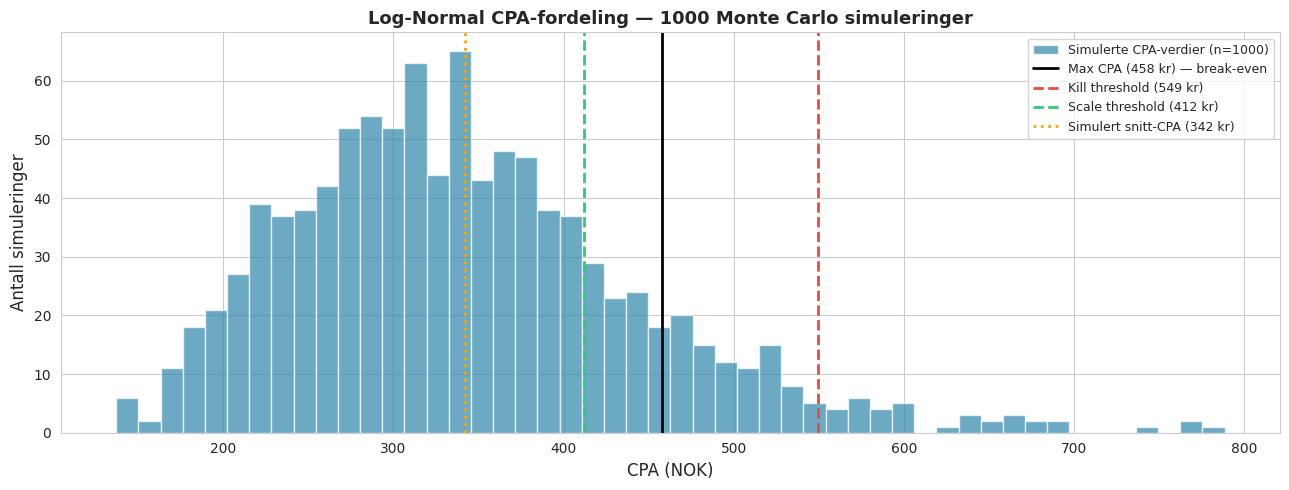

CPA i SCALE-sone (<412 kr): 78.8%
CPA i HOLD-sone:                                       17.1%
CPA i KILL-sone  (>549 kr): 4.1%


In [3]:
# Hent simulerte data
result = sim.predict(daily_budget=500, expected_cpa=350, days=14)
cpas   = result['simulated_cpas']

fig, ax = plt.subplots(figsize=(13, 5))

# Histogram av simulerte CPA-verdier
ax.hist(cpas, bins=50, color='#2E86AB', alpha=0.7, edgecolor='white',
        label='Simulerte CPA-verdier (n=1000)')

# Markér viktige terskler
ax.axvline(engine.max_cpa,
           color='black', linewidth=2, linestyle='-',
           label=f'Max CPA ({engine.max_cpa:.0f} kr) — break-even')
ax.axvline(engine.max_cpa * engine.kill_threshold,
           color='#e74c3c', linewidth=2, linestyle='--',
           label=f'Kill threshold ({engine.max_cpa * engine.kill_threshold:.0f} kr)')
ax.axvline(engine.max_cpa * engine.scale_threshold,
           color='#2ecc71', linewidth=2, linestyle='--',
           label=f'Scale threshold ({engine.max_cpa * engine.scale_threshold:.0f} kr)')
ax.axvline(cpas.mean(),
           color='orange', linewidth=2, linestyle=':',
           label=f'Simulert snitt-CPA ({cpas.mean():.0f} kr)')

ax.set_xlabel('CPA (NOK)', fontsize=12)
ax.set_ylabel('Antall simuleringer', fontsize=12)
ax.set_title('Log-Normal CPA-fordeling — 1000 Monte Carlo simuleringer',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Beregn andel i hver sone
scale_zone = (cpas < engine.max_cpa * engine.scale_threshold).mean() * 100
kill_zone  = (cpas > engine.max_cpa * engine.kill_threshold).mean()  * 100
hold_zone  = 100 - scale_zone - kill_zone

print(f'CPA i SCALE-sone (<{engine.max_cpa * engine.scale_threshold:.0f} kr): {scale_zone:.1f}%')
print(f'CPA i HOLD-sone:                                       {hold_zone:.1f}%')
print(f'CPA i KILL-sone  (>{engine.max_cpa * engine.kill_threshold:.0f} kr): {kill_zone:.1f}%')

<h2 style="border-bottom:2px solid #555; padding-bottom:6px">📌 Visualisering — Profit-fordeling</h2>
<p>Her ser vi fordelingen av simulerte profitter og hva p10/mean/p90 betyr visuelt.</p>

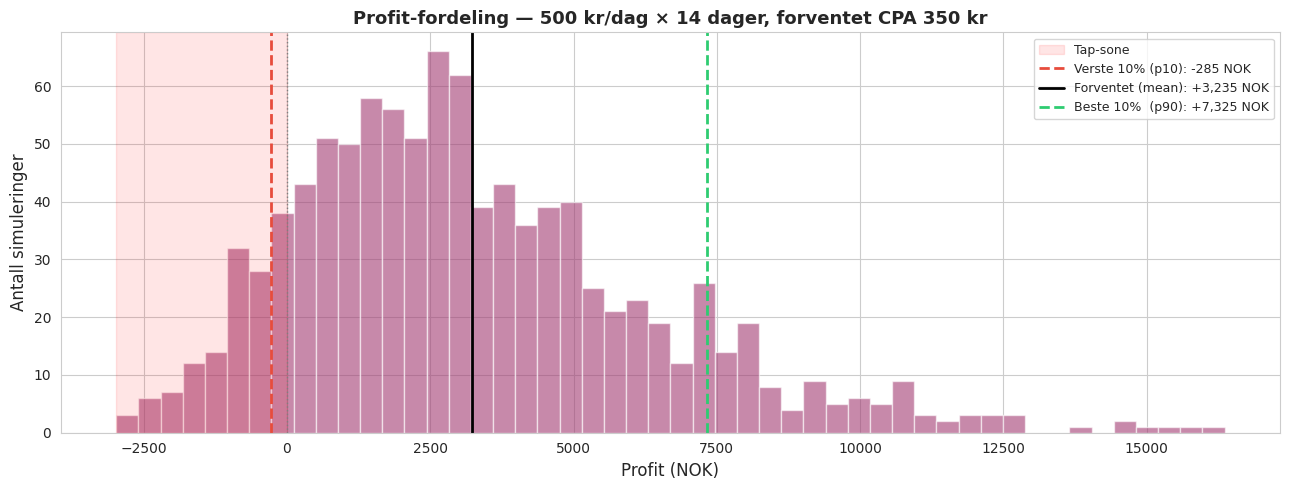

In [4]:
profits = result['simulated_profits']
p10     = np.percentile(profits, 10)
p90     = np.percentile(profits, 90)
mean    = profits.mean()

fig, ax = plt.subplots(figsize=(13, 5))

# Histogram
ax.hist(profits, bins=50, color='#A23B72', alpha=0.6, edgecolor='white')

# Fyll tap-sonen rødt
ax.axvspan(profits.min(), 0, alpha=0.1, color='red', label='Tap-sone')

# Markér p10, mean, p90
ax.axvline(p10,  color='#e74c3c', linewidth=2, linestyle='--',
           label=f'Verste 10% (p10): {p10:+,.0f} NOK')
ax.axvline(mean, color='black',   linewidth=2, linestyle='-',
           label=f'Forventet (mean): {mean:+,.0f} NOK')
ax.axvline(p90,  color='#2ecc71', linewidth=2, linestyle='--',
           label=f'Beste 10%  (p90): {p90:+,.0f} NOK')
ax.axvline(0,    color='grey',    linewidth=1, linestyle=':')

ax.set_xlabel('Profit (NOK)', fontsize=12)
ax.set_ylabel('Antall simuleringer', fontsize=12)
ax.set_title('Profit-fordeling — 500 kr/dag × 14 dager, forventet CPA 350 kr',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

<h2 style="border-bottom:2px solid #555; padding-bottom:6px">📌 Visualisering — Sammenlign tre strategier</h2>
<p>La oss sammenligne forsiktig, standard og aggressiv strategi side om side.</p>

A — Forsiktig                  | SCALE   0.2% | Forv. profit:    +579 NOK | Verste:    -110 NOK
B — Standard                   | SCALE  80.5% | Forv. profit:  +2,957 NOK | Verste:    -353 NOK
C — Aggressiv                  | SCALE  78.8% | Forv. profit:  +6,085 NOK | Verste:    -699 NOK



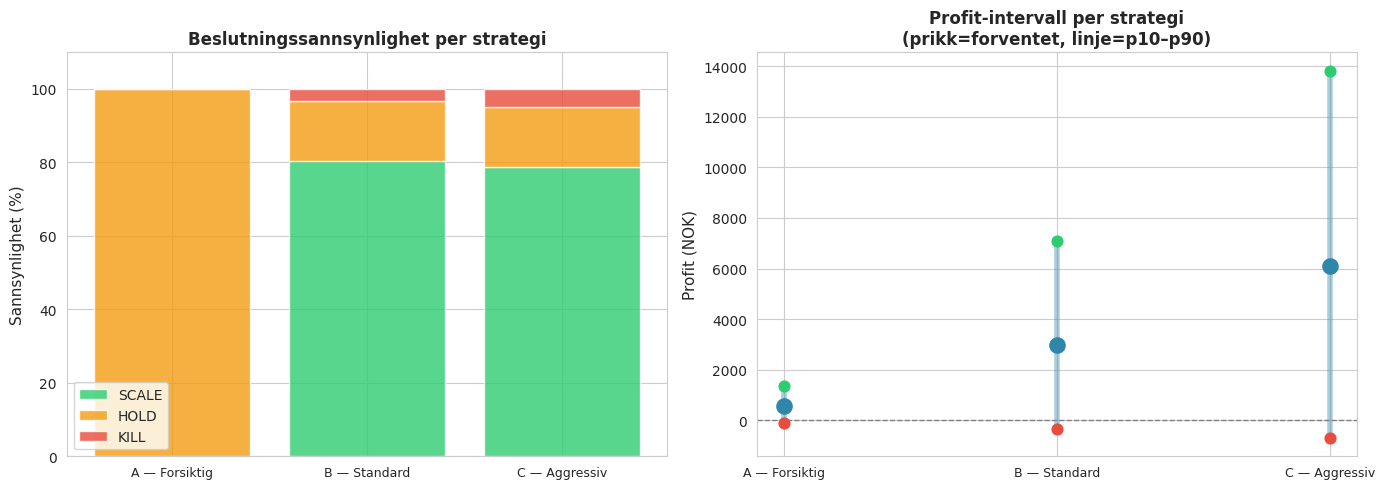

In [5]:
strategier = [
    ('A — Forsiktig\n200 kr/dag × 7 dager',  200,  350, 7),
    ('B — Standard\n500 kr/dag × 14 dager',  500,  350, 14),
    ('C — Aggressiv\n1000 kr/dag × 14 dager', 1000, 350, 14),
]

resultater = []
for label, budget, cpa, days in strategier:
    r = sim.predict(daily_budget=budget, expected_cpa=cpa, days=days)
    resultater.append((label, r))
    print(f'{label.split(chr(10))[0]:30} | '
          f'SCALE {r["scale_probability"]:5.1f}% | '
          f'Forv. profit: {r["profit_mean"]:+7,.0f} NOK | '
          f'Verste: {r["profit_p10"]:+7,.0f} NOK')

print()

# Stablet bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels        = [r[0].split('\n')[0] for r in resultater]
scale_probs   = [r[1]['scale_probability'] for r in resultater]
hold_probs    = [r[1]['hold_probability']  for r in resultater]
kill_probs    = [r[1]['kill_probability']  for r in resultater]
profit_means  = [r[1]['profit_mean']       for r in resultater]
profit_p10s   = [r[1]['profit_p10']        for r in resultater]
profit_p90s   = [r[1]['profit_p90']        for r in resultater]

x = range(len(labels))

# Plot 1: Sannsynligheter
axes[0].bar(x, scale_probs, color='#2ecc71', alpha=0.8, label='SCALE')
axes[0].bar(x, hold_probs,  color='#f39c12', alpha=0.8, label='HOLD',
            bottom=scale_probs)
axes[0].bar(x, kill_probs,  color='#e74c3c', alpha=0.8, label='KILL',
            bottom=[s + h for s, h in zip(scale_probs, hold_probs)])
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, fontsize=9)
axes[0].set_ylabel('Sannsynlighet (%)', fontsize=11)
axes[0].set_title('Beslutningssannsynlighet per strategi', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].set_ylim(0, 110)

# Plot 2: Profit-intervaller
for i, (label, r) in enumerate(resultater):
    axes[1].plot([i, i], [r['profit_p10'], r['profit_p90']],
                 color='#2E86AB', linewidth=4, alpha=0.4)
    axes[1].scatter(i, r['profit_mean'], s=120, color='#2E86AB', zorder=5)
    axes[1].scatter(i, r['profit_p10'],  s=60,  color='#e74c3c', zorder=5)
    axes[1].scatter(i, r['profit_p90'],  s=60,  color='#2ecc71', zorder=5)

axes[1].axhline(0, color='grey', linewidth=1, linestyle='--')
axes[1].set_xticks(range(len(labels)))
axes[1].set_xticklabels(labels, fontsize=9)
axes[1].set_ylabel('Profit (NOK)', fontsize=11)
axes[1].set_title('Profit-intervall per strategi\n(prikk=forventet, linje=p10–p90)',
                  fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

<h2 style="border-bottom:2px solid #555; padding-bottom:6px">✅ Key Takeaways</h2>
<ul>
  <li><b>Ett tall er ikke nok</b> — du trenger et spekter (p10, mean, p90) for å forstå risiko</li>
  <li><b>Monte Carlo</b> simulerer 1000 mulige utfall og gir deg sannsynligheter, ikke gjetninger</li>
  <li><b>Log-normal fordeling</b> modellerer CPA realistisk — alltid positiv, høyreskjev</li>
  <li><b>SCALE 80%</b> betyr ikke garanti — men oddsen er sterkt på din side</li>
  <li><b>Sammenlign strategier</b> før du bruker ekte penger — simulatoren er gratis</li>
  <li><b>Valider forventningene</b> med en liten test-kampanje, juster cpa-estimat, kjør ny simulering</li>
  <li>De tre modulene henger sammen: <b>BreakEven → KPI Engine → Simulator</b></li>
</ul>
<hr>

<h2 style="border-bottom:2px solid #555; padding-bottom:6px">❓ Refleksjonsspørsmål</h2>
<ol>
  <li>Hvorfor gir ett enkelt profit-tall (f.eks. 3 000 kr) utilstrekkelig informasjon for beslutning?</li>
  <li>Forklar med egne ord hva Monte Carlo simulering er og hvorfor 1000 kjøringer brukes.</li>
  <li>Hvorfor er log-normal fordeling mer realistisk enn normalfordeling for CPA?</li>
  <li>Du ser p10 = -500 kr og p90 = +8 000 kr. Hva sier dette om kampanjens risikoprofil?</li>
  <li>Hva betyr SCALE 60% vs. SCALE 90% i praksis — og hvordan påvirker det beslutningen din?</li>
  <li>Hvorfor bør du alltid starte med en liten test-kampanje (Strategi A) fremfor å gå rett på Strategi C?</li>
</ol>
<hr>

<h2 style="border-bottom:2px solid #555; padding-bottom:6px">🎯 Neste steg</h2>
<p>Lab-en er nå komplett med tre moduler:</p>
<ul>
  <li>✅ <b>BreakEvenCalculator</b> — hva er max CPA og break-even ROAS?</li>
  <li>✅ <b>KPIDecisionEngine</b> — scale, hold eller kill basert på faktiske data?</li>
  <li>✅ <b>CampaignSimulator</b> — hva er sannsynlig å skje med dette budsjettet?</li>
</ul>
<p>Mulige neste steg:</p>
<ul>
  <li>Koble inn <b>ekte kampanje-data</b> fra Meta Ads eller Google Ads</li>
  <li>Bygge et <b>dashboard</b> med ipywidgets for interaktiv simulering</li>
  <li>Legge til <b>tidsserie-analyse</b> — CPA-trender over uker og måneder</li>
</ul>